# L'impronta semantica degli LLM: Analisi comparativa tra musica reale e artificiale

### Progetto — corso *Tecnologie dei dati e del linguaggio* (Traccia 3)
### Generazione con modello locale + corpus reale via Genius API ufficiale
**Autore:** _Francesca Bubba_



## 1. Domanda di ricerca e ipotesi

**Domanda di ricerca:** un LLM, generando testi di canzoni per generi musicali legati a tradizioni culturali diverse, tende a renderli più simili tra loro (in termini semantici) rispetto a quanto lo siano realmente i testi originali dello stesso genere?

**Ipotesi:** nel corpus reale, i generi musicali restano linguisticamente e tematicamente più distinti tra loro rispetto ai testi generati dal modello, che tendono invece a un maggiore appiattimento reciproco (misurato come similarità semantica più alta tra coppie di generi).

## 2. Fonti e dati

**Testi generati:** prodotti da un modello open-weight scaricato da Hugging Face ed eseguito localmente sulla GPU/CPU di Colab — [`Qwen/Qwen2.5-3B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct), non gated (non richiede account o token Hugging Face).

**Corpus di riferimento (testi reali):** raccolto tramite la [Genius API ufficiale](https://docs.genius.com/) con il pacchetto [`lyricsgenius`](https://pypi.org/project/lyricsgenius/). Richiede un token gratuito, ottenibile registrando un'app su [genius.com/api-clients](https://genius.com/api-clients) (nessun costo, nessuna approvazione manuale). Selezione di partenza di artisti/brani rappresentativi per ciascun genere — da motivare/rivedere criticamente nella relazione.

**Traduzione (normalizzazione multilingue):** libreria [`deep-translator`](https://pypi.org/project/deep-translator/) (nessuna chiave richiesta).

**Strumento per l'analisi semantica:** [`sentence-transformers`](https://www.sbert.net/) (modello multilingue `paraphrase-multilingual-MiniLM-L12-v2`, scaricato pubblicamente senza autenticazione).

**Letteratura di riferimento:**
- Bender, E. M. et al. (2021). *On the Dangers of Stochastic Parrots.* FAccT.
- Blodgett, S. L. et al. (2020). *Language (Technology) is Power: A Critical Survey of "Bias" in NLP.* ACL.

**Nota:** un tentativo iniziale di raccogliere i testi reali tramite scraping delle pagine pubbliche di Genius.com è stato abbandonato perché il sito blocca attivamente le richieste automatizzate (errore 403) e i suoi Termini di Servizio vietano lo scraping — da qui la scelta della Genius API ufficiale, gratuita e conforme.

## 3. Metodologia — panoramica

1. Definizione di generi musicali e temi fissi, con un unico prompt per la generazione.
2. Generazione dei testi con un modello Hugging Face locale (più ripetizioni per genere/tema).
3. Raccolta del corpus reale di riferimento tramite la Genius API ufficiale.
4. Preprocessing (pulizia, normalizzazione linguistica tramite traduzione in italiano).
5. Calcolo degli embedding semantici e delle matrici di similarità tra generi (generati vs reali).
6. Verifica statistica dell'ipotesi (test di Wilcoxon sulle coppie di similarità).

In [1]:
# Installazione pacchetti necessari (eseguire una sola volta su Colab)
# Suggerimento: Runtime > Cambia tipo di runtime > GPU (T4), per velocizzare la generazione locale.
!pip install transformers accelerate sentencepiece torch lyricsgenius deep-translator sentence-transformers pandas numpy matplotlib seaborn scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.4 MB/s eta 0:00:00


## 4. Caricamento del modello locale (nessuna chiave richiesta)

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"  # modello aperto, non gated: nessun account/token necessario

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)
print("Modello caricato su:", model.device)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modello caricato su: cuda:0


## 5. Generi musicali, temi e prompt

In [3]:
GENRES = {
    "trap italiana":    "Italia",
    "pop anglosassone": "USA/UK",
    "reggaeton":        "America Latina/Caraibi",
    "K-pop":            "Corea del Sud",
    "afrobeats":        "Africa occidentale (Nigeria/Ghana)",
    "fado":             "Portogallo",
}

THEMES = ["amore", "festa", "nostalgia"]

N_REPEATS = 3  # generazioni per ogni combinazione genere x tema
# 6 generi x 3 temi x 3 ripetizioni = 54 testi: abbastanza per un test statistico,
# gestibile in pochi minuti anche su GPU T4. Aumenta a 8-10 solo se hai tempo prima
# della lezione (piu dati = risultati piu robusti, ma piu lento da generare).

PROMPT_TEMPLATE = (
    'Scrivi il testo di una canzone {genre} sul tema "{theme}". '
    "Scrivi solo il testo della canzone, senza commenti."
)

## 6. Generazione dei testi con il modello locale (versione batch, con cache)

I prompt vengono raggruppati in batch per sfruttare la GPU in parallelo (5-10x più veloce della generazione singola). Inoltre: **se `testi_generati.csv` esiste già** (da un'esecuzione precedente), la cella lo ricarica invece di rigenerare — utile per non dover aspettare di nuovo il giorno della presentazione. Per forzare una nuova generazione, cancella il file o metti `FORZA_RIGENERAZIONE = True`.

In [4]:
import pandas as pd
import torch
import os

FORZA_RIGENERAZIONE = False  # metti True per rigenerare anche se il CSV esiste gia
PERCORSO_CSV_GENERATI = "testi_generati.csv"

if os.path.exists(PERCORSO_CSV_GENERATI) and not FORZA_RIGENERAZIONE:
    df_generated = pd.read_csv(PERCORSO_CSV_GENERATI)
    print(f"Caricati {len(df_generated)} testi da {PERCORSO_CSV_GENERATI} (nessuna nuova generazione).")
else:
    tokenizer.padding_side = "left"  # necessario per generazione batch con modelli decoder-only
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    BATCH_SIZE = 8  # riduci se vai in errore di memoria GPU (es. a 4)

    def genera_batch(prompts, max_new_tokens=200, batch_size=BATCH_SIZE):
        testi_generati = []
        n_batch_tot = (len(prompts) - 1) // batch_size + 1
        for i in range(0, len(prompts), batch_size):
            batch_prompts = prompts[i:i + batch_size]
            messages_batch = [[{"role": "user", "content": p}] for p in batch_prompts]
            testi_input = [
                tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
                for m in messages_batch
            ]
            inputs = tokenizer(testi_input, return_tensors="pt", padding=True).to(model.device)
            with torch.no_grad():
                output = model.generate(
                    **inputs, max_new_tokens=max_new_tokens, do_sample=True,
                    temperature=0.9, top_p=0.9, pad_token_id=tokenizer.pad_token_id,
                )
            lunghezza_input = inputs["input_ids"].shape[1]
            for j in range(len(batch_prompts)):
                testo = tokenizer.decode(output[j][lunghezza_input:], skip_special_tokens=True)
                testi_generati.append(testo)
            print(f"Batch {i // batch_size + 1}/{n_batch_tot} completato")
        return testi_generati

    combinazioni = [
        (genere, tema, i)
        for genere in GENRES
        for tema in THEMES
        for i in range(N_REPEATS)
    ]
    prompts = [PROMPT_TEMPLATE.format(genre=g, theme=t) for g, t, _ in combinazioni]

    testi = genera_batch(prompts)

    records = [
        {"genere": genere, "tema": tema, "ripetizione": i, "prompt": prompt, "testo": testo, "fonte": "generato_llm"}
        for (genere, tema, i), prompt, testo in zip(combinazioni, prompts, testi)
    ]

    df_generated = pd.DataFrame(records)
    df_generated.to_csv(PERCORSO_CSV_GENERATI, index=False)
    print(f"Generati {len(df_generated)} testi e salvati in {PERCORSO_CSV_GENERATI}.")

df_generated.head()

Batch 1/7 completato
Batch 2/7 completato
Batch 3/7 completato
Batch 4/7 completato
Batch 5/7 completato
Batch 6/7 completato
Batch 7/7 completato
Generati 54 testi e salvati in testi_generati.csv.


,genere,tema,ripetizione,prompt,testo,fonte
0,trap italiana,amore,0,Scrivi il testo di una canzone trap italiana s...,"(Chorus)\nAmore, amore che si rompe\nSotto la ...",generato_llm
1,trap italiana,amore,1,Scrivi il testo di una canzone trap italiana s...,"(Refrain)\nOh baby, oh love baby, \nNon hai i...",generato_llm
2,trap italiana,amore,2,Scrivi il testo di una canzone trap italiana s...,"(Preghiera)\n\nChe io vada a te come vento,\nc...",generato_llm
3,trap italiana,festa,0,Scrivi il testo di una canzone trap italiana s...,Ecco la melodia e le parole di una canzone Tra...,generato_llm
4,trap italiana,festa,1,Scrivi il testo di una canzone trap italiana s...,"(Drum Loop)\nRisuona la festa, luce si allarga...",generato_llm


In [5]:
!pip install langdetect -q

import pandas as pd
import os
import re # Required for pulisci_testo
from langdetect import detect # Required for traduci_in_italiano
from deep_translator import GoogleTranslator # Required for traduci_in_italiano

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # Mostra anche il testo completo senza tagliarlo

# Define helper functions from cell 9lx-Iif6lHeO to make this cell self-sufficient
def pulisci_testo(testo):
    if not isinstance(testo, str):
        return ""
    t = testo.lower()
    t = re.sub(r"\[.*?\]", " ", t)
    t = re.sub(r"[^\\w\\sàèéìòù']", " ", t)
    t = re.sub(r"\\d+", " ", t)
    t = re.sub(r"\\s+", " ", t).strip()
    return t

def traduci_in_italiano(testo):
    if not isinstance(testo, str) or len(testo.strip()) == 0:
        return testo
    try:
        lingua = detect(testo)
    except Exception:
        lingua = "unknown"
    if lingua == "it":
        return testo
    try:
        # deep-translator ha un limite di caratteri per richiesta: tronchiamo se necessario
        return GoogleTranslator(source="auto", target="it").translate(testo[:4500])
    except Exception as e:
        print(f"Traduzione fallita durante ri-generazione in VB_rktERAvwz: {e}")
        return testo

PERCORSO_CSV_GENERATI = "testi_generati.csv" # Path to original generated texts
PERCORSO_CSV_GENERATI_IT = "testi_generati_it.csv" # Path to cleaned and translated generated texts

# Check if df_generated (the processed one) is defined or its IT CSV exists
if ('df_generated' not in locals() and 'df_generated' not in globals()) or not os.path.exists(PERCORSO_CSV_GENERATI_IT):
    # If not in memory OR IT CSV is missing, try to (re)load and process
    if os.path.exists(PERCORSO_CSV_GENERATI_IT):
        df_generated = pd.read_csv(PERCORSO_CSV_GENERATI_IT)
        print(f"df_generated caricato da '{PERCORSO_CSV_GENERATI_IT}'.")
    elif os.path.exists(PERCORSO_CSV_GENERATI):
        print(f"File '{PERCORSO_CSV_GENERATI_IT}' non trovato. Riprocessando da '{PERCORSO_CSV_GENERATI}'.")
        df_generated = pd.read_csv(PERCORSO_CSV_GENERATI)

        # Re-process if the IT version is missing
        df_generated["testo_pulito"] = df_generated["testo"].apply(pulisci_testo)
        df_generated["testo_it"] = df_generated["testo_pulito"].apply(traduci_in_italiano)
        df_generated.to_csv(PERCORSO_CSV_GENERATI_IT, index=False)
        print(f"df_generated ri-generato e salvato in '{PERCORSO_CSV_GENERATI_IT}'.")
    else:
        print(f"Errore: df_generated non definito e né '{PERCORSO_CSV_GENERATI_IT}' né '{PERCORSO_CSV_GENERATI}' sono stati trovati. Assicurati di aver eseguito le celle precedenti che generano e salvano questo DataFrame.")
        df_generated = None # Ensure df_generated is not referenced if not loaded
else:
    print("df_generated già definito in memoria o caricato con successo dal CSV IT.")

# Display df_generated only if it has been successfully defined/loaded/re-generated
if 'df_generated' in locals() or 'df_generated' in globals():
    if df_generated is not None:
        display(df_generated)
    else:
        print("Impossibile mostrare df_generated perché non è stato caricato o generato.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
File 'testi_generati_it.csv' non trovato. Riprocessando da 'testi_generati.csv'.
df_generated ri-generato e salvato in 'testi_generati_it.csv'.


,genere,tema,ripetizione,prompt,testo,fonte,testo_pulito,testo_it
0,trap italiana,amore,0,"Scrivi il testo di una canzone trap italiana sul tema ""amore"". Scrivi solo il testo della canzone, senza commenti.","(Chorus)\nAmore, amore che si rompe\nSotto la tua luce di stelle\nSento i tuoi baci come pioggia\nDi notte, quando tutto è buio\n\n(Refrain)\nTi amo, ti amo in questo mondo\nSotto questa luna che non conosce fine\nNon c'è spazio tra noi\nNessun confine, nessun limite\n\n(Bridge)\nNon voglio più aspettare\nNon voglio più rimanere incerti\nVoglio il tuo amore, il mio alone\nDove mai andiamo insieme\n\n(Chorus)\nAmore, amore che si rompe\nSotto la tua luce di stelle\nSento i tuoi baci come pioggia\nDi notte, quando tutto è buio\n\n(Refrain)\nTi amo, ti amo in questo mondo\nSotto questa luna che non conosce",generato_llm,s s s s s è s s s s 'è s ss ss ù s ù s s s s s s è s s s s,s s s s è s s s 'è ss ssù sù s s s s s è s s s
1,trap italiana,amore,1,"Scrivi il testo di una canzone trap italiana sul tema ""amore"". Scrivi solo il testo della canzone, senza commenti.","(Refrain)\nOh baby, oh love baby, \nNon hai idea di quanto sei speciale, \nCerte volte mi sento così piccolo, \nMa tu rendi tutto bello.\n\n(Chorus)\nAmore è la luce che mi illumina, \nSei la mia fiaba, la mia stella, \nSei la cosa più grande che ho mai visto, \nAmore, amore, amore, amore.\n\n(Refrain)\nOh baby, oh love baby, \nNon hai idea di quanto sei speciale, \nCerte volte mi sento così piccolo, \nMa tu rendi tutto bello.\n\n(Duet)\nTi amo, ti amo, ti amo, ti amo, \nTi amo, ti amo, ti amo, ti amo, \nMi manchi quando non ci siamo, \nMi manchi sempre.\n\n(Chorus)\nAmore è il suono del mio cuore, \nSei l'unico",generato_llm,s s s sì s è s s s s ù s s s s sì s s s è s s ',s s s sì s è s s s ù s s s s sì s s è s '
2,trap italiana,amore,2,"Scrivi il testo di una canzone trap italiana sul tema ""amore"". Scrivi solo il testo della canzone, senza commenti.","(Preghiera)\n\nChe io vada a te come vento,\nche tu mi ritorni come luna.\nIo t'amo, ti amo, amore mio,\ntuo cuore è la mia terra.\n\n(Turno)\n\nSotto le stelle ci incontreremo,\ndove il tempo si ferma e le pietre parlano.\nTu sei l'ombra che mi segua,\nl'amore che fa mille sogni.\n\n(Lamento)\n\nDove il sole è lontano,\ne l'oscurità è il regno più caldo,\nio ti cercherò come un pugnale,\ne tu mi porterai via come una stella.\n\n(Apre)\n\nTuo corpo mi divora,\ncome il fuoco divora le braci.\nL'acqua mi fa ballare,\ne tu mi fai cantare.\n\n(Turno)\n\nOgni notte che passa insieme,\nil nostro amore si",generato_llm,' è s s s s ' s ' s s è ' s à è ù ò s ' ss s s s,' è s s s ' s ' s s è ' s à è ù ò s ' ss s s
3,trap italiana,festa,0,"Scrivi il testo di una canzone trap italiana sul tema ""festa"". Scrivi solo il testo della canzone, senza commenti.","Ecco la melodia e le parole di una canzone Trap italiana su ""festa"":\n\n(Preseguono 24 barre)\n\nVerse 1:\nNel centro del parcheggio, ci sono noi\nSotto le luci che danzano, sull'oceano di storie \nRipetiamo i nostri brani preferiti, con gli orecchini d'oro\nI flash non ce li mettiamo, ma gli occhi si abbronzano\n\nBridge:\nOh oh, oh oh\nFesta fatta, festa vista, festa da far ballare\nLe voci al cielo, le teste che scendono per ballare\nQuando la musica ci raggiunge, l'aria diventa un brivido\nIn quel momento, il mondo è solo noi due\n\nChorus:\nFesta, festa, festa\nFesta, festa, festa\nFesta,",generato_llm,s s s s s s s ' s s ' s s s s s s s s s ' è s s s s s s s s s,sssssssss'ss'ssssssssssssss' èsssssssssss
4,trap italiana,festa,1,"Scrivi il testo di una canzone trap italiana sul tema ""festa"". Scrivi solo il testo della canzone, senza commenti.","(Drum Loop)\nRisuona la festa, luce si allarga,\nMusica che sale, in alto ci si alza.\nBraccia aperte, cuori si scambiano,\nCade la notte, festeggiando il giorno.\n\n(Chorus)\nSiamo in festa, noi la festa è tutto,\nFesteggiamo, sappiamo non tornare più qui.\nLa musica è un fiotto, il cielo è stelle brillanti,\nSiamo in fes

## 7. Raccolta del corpus reale tramite Genius API ufficiale

Serve un token gratuito: vai su [genius.com/api-clients](https://genius.com/api-clients), crea una "API Client" (bastano nome e sito web fittizio, es. il tuo repo GitHub), poi genera un "Client Access Token" dalla pagina dell'app creata. Incolla il token quando richiesto dalla cella seguente (non viene salvato nel notebook — meglio ancora, salvalo nei Secrets di Colab col nome `GENIUS_ACCESS_TOKEN`).

Anche qui: **se `testi_reali.csv` esiste già, non serve nemmeno il token** — la cella salta direttamente al caricamento da file.

In [6]:
import os

PERCORSO_CSV_REALI = "testi_reali.csv"

if not os.path.exists(PERCORSO_CSV_REALI):
    GENIUS_ACCESS_TOKEN = None
    try:
        from google.colab import userdata
        GENIUS_ACCESS_TOKEN = userdata.get("GENIUS_ACCESS_TOKEN")
        print("Token caricato dai Secrets di Colab.")
    except Exception:
        pass

    if not GENIUS_ACCESS_TOKEN:
        import getpass
        print("Secret non trovato: inseriscilo manualmente qui sotto (scrivi e premi Invio).")
        GENIUS_ACCESS_TOKEN = getpass.getpass("Genius API access token: ")

    import lyricsgenius
    genius = lyricsgenius.Genius(
        GENIUS_ACCESS_TOKEN, remove_section_headers=True, skip_non_songs=True,
        timeout=15
    )
else:
    print(f"{PERCORSO_CSV_REALI} gia presente: token non necessario, si carica direttamente il file.")

Secret non trovato: inseriscilo manualmente qui sotto (scrivi e premi Invio).
Genius API access token: ··········


In [7]:
import pandas as pd
import os
import requests

FORZA_RIRACCOLTA = False
PERCORSO_CSV_REALI = "testi_reali.csv"

if os.path.exists(PERCORSO_CSV_REALI) and not FORZA_RIRACCOLTA:
    df_real = pd.read_csv(PERCORSO_CSV_REALI)
    print(f"Caricati {len(df_real)} testi reali da {PERCORSO_CSV_REALI}.")
else:
    # Corpus alternativo tramite API pubblica OVH senza API key
    brani = [
        ("trap italiana", "Sfera Ebbasta", "Cupido"),
        ("trap italiana", "Capo Plaza", "Tesla"),
        ("trap italiana", "Lazza", "Cenere"),
        ("pop anglosassone", "Taylor Swift", "Blank Space"),
        ("pop anglosassone", "Ed Sheeran", "Shape of You"),
        ("pop anglosassone", "Dua Lipa", "Levitating"),
        ("reggaeton", "Bad Bunny", "Tití Me Preguntó"),
        ("reggaeton", "Daddy Yankee", "Gasolina"),
        ("reggaeton", "Karol G", "PROVENZA"),
        ("K-pop", "BTS", "Dynamite"),
        ("K-pop", "BLACKPINK", "Pink Venom"),
        ("K-pop", "Stray Kids", "MANIAC"),
        ("afrobeats", "Burna Boy", "Last Last"),
        ("afrobeats", "Wizkid", "Essence"),
        ("afrobeats", "Davido", "Unavailable"),
        ("fado", "Amália Rodrigues", "Fado Português"),
        ("fado", "Mariza", "Gente da Minha Terra"),
        ("fado", "Ana Moura", "Desfado"),
    ]

    real_records = []
    headers = {'User-Agent': 'Mozilla/5.0'}

    for genere, artista, titolo in brani:
        try:
            url = f"https://api.lyrics.ovh/v1/{artista}/{titolo}"
            r = requests.get(url, headers=headers, timeout=10)
            if r.status_code == 200:
                data = r.json()
                testo = data.get("lyrics", "")
                if testo:
                    real_records.append({
                        "genere": genere, "artista": artista,
                        "titolo": titolo, "testo": testo, "fonte": "corpus_reale"
                    })
                    print(f"OK: {artista} - {titolo}")
            else:
                print(f"Non trovato: {artista} - {titolo}")
        except Exception as e:
            print(f"Errore con {artista} - {titolo}: {e}")

    df_real = pd.DataFrame(real_records)
    df_real.to_csv(PERCORSO_CSV_REALI, index=False)
    print(f"\nRaccolti {len(df_real)} testi reali e salvati in {PERCORSO_CSV_REALI}.")

OK: Sfera Ebbasta - Cupido
OK: Capo Plaza - Tesla
OK: Lazza - Cenere
OK: Taylor Swift - Blank Space
OK: Ed Sheeran - Shape of You
OK: Dua Lipa - Levitating
OK: Bad Bunny - Tití Me Preguntó
OK: Daddy Yankee - Gasolina
OK: Karol G - PROVENZA
OK: BTS - Dynamite
OK: BLACKPINK - Pink Venom
OK: Stray Kids - MANIAC
OK: Burna Boy - Last Last
OK: Wizkid - Essence
OK: Davido - Unavailable
Non trovato: Amália Rodrigues - Fado Português
Non trovato: Mariza - Gente da Minha Terra
OK: Ana Moura - Desfado

Raccolti 16 testi reali e salvati in testi_reali.csv.


## 8. Preprocessing e normalizzazione linguistica

I generi coprono lingue diverse (italiano, inglese, spagnolo, coreano, portoghese...). Per rendere confrontabili gli embedding, i testi non italiani vengono tradotti in italiano con `deep-translator` (nessuna chiave richiesta) — un passaggio esplicito da discutere come possibile limite: la traduzione stessa potrebbe introdurre un ulteriore appiattimento, da tenere distinto da quello attribuibile alla generazione.

In [8]:
!pip install langdetect -q

import re
from langdetect import detect
from deep_translator import GoogleTranslator

PERCORSO_CSV_GENERATI_IT = "testi_generati_it.csv"
PERCORSO_CSV_REALI_IT = "testi_reali_it.csv"

def pulisci_testo(testo):
    if not isinstance(testo, str):
        return ""
    t = testo.lower()
    t = re.sub(r"\[.*?\]", " ", t)
    t = re.sub(r"[^\w\sàèéìòù']", " ", t)
    t = re.sub(r"\d+", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def traduci_in_italiano(testo):
    if not isinstance(testo, str) or len(testo.strip()) == 0:
        return testo
    try:
        lingua = detect(testo)
    except Exception:
        lingua = "unknown"
    if lingua == "it":
        return testo
    try:
        # deep-translator ha un limite di caratteri per richiesta: tronchiamo se necessario
        return GoogleTranslator(source="auto", target="it").translate(testo[:4500])
    except Exception as e:
        print(f"Traduzione fallita: {e}")
        return testo

if os.path.exists(PERCORSO_CSV_GENERATI_IT) and os.path.exists(PERCORSO_CSV_REALI_IT):
    df_generated = pd.read_csv(PERCORSO_CSV_GENERATI_IT)
    df_real = pd.read_csv(PERCORSO_CSV_REALI_IT)
    print("Testi puliti/tradotti gia presenti su disco: ricaricati senza rifare pulizia/traduzione.")
else:
    df_generated["testo_pulito"] = df_generated["testo"].apply(pulisci_testo)
    df_real["testo_pulito"] = df_real["testo"].apply(pulisci_testo)

    df_generated["testo_it"] = df_generated["testo_pulito"].apply(traduci_in_italiano)
    df_real["testo_it"] = df_real["testo_pulito"].apply(traduci_in_italiano)

    df_generated.to_csv(PERCORSO_CSV_GENERATI_IT, index=False)
    df_real.to_csv(PERCORSO_CSV_REALI_IT, index=False)
    print("Pulizia e traduzione completate e salvate su disco.")

Pulizia e traduzione completate e salvate su disco.


## 9. Embedding semantici e similarità tra generi

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

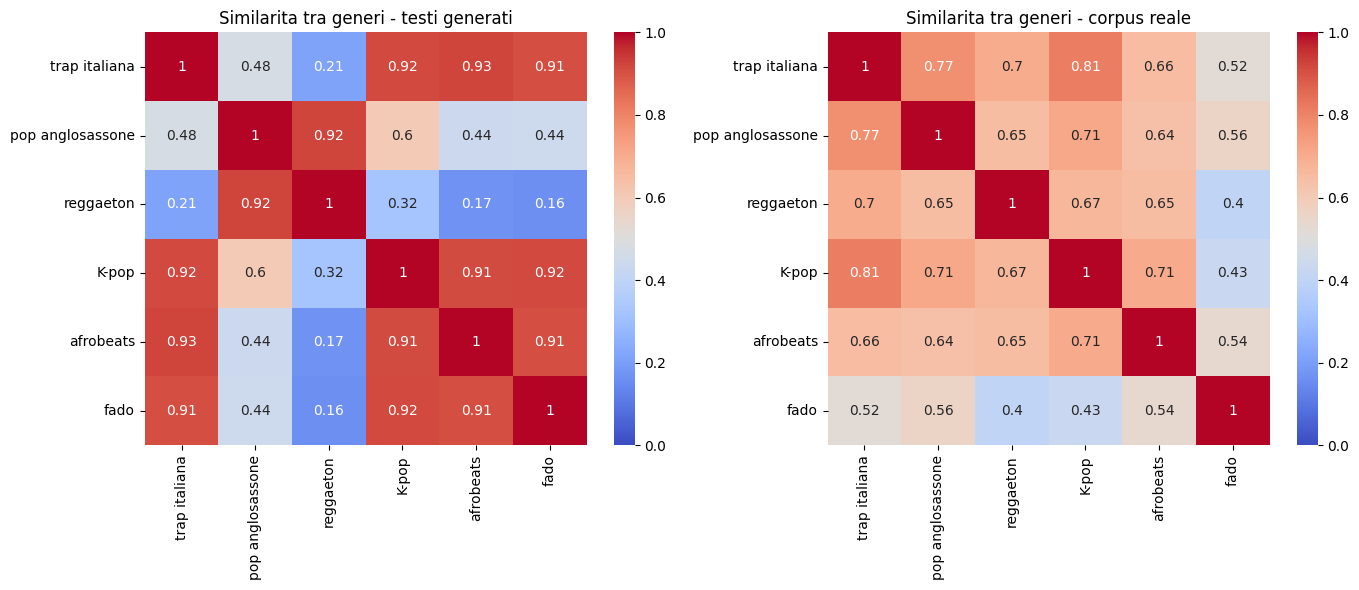

In [9]:
import numpy as np
from sentence_transformers import SentenceTransformer
import seaborn as sns
import matplotlib.pyplot as plt

modello_embedding = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def embedding_medio_per_genere(df, colonna_testo, colonna_gruppo):
    medie = {}
    for gruppo, sotto_df in df.groupby(colonna_gruppo):
        testi = sotto_df[colonna_testo].dropna().tolist()
        if not testi:
            continue
        emb = modello_embedding.encode(testi)
        medie[gruppo] = emb.mean(axis=0)
    return medie

emb_generati = embedding_medio_per_genere(df_generated, "testo_it", "genere")
emb_reali = embedding_medio_per_genere(df_real, "testo_it", "genere")

def matrice_similarita(embeddings_dict, ordine_generi):
    matrice = np.zeros((len(ordine_generi), len(ordine_generi)))
    for i, g1 in enumerate(ordine_generi):
        for j, g2 in enumerate(ordine_generi):
            v1, v2 = embeddings_dict[g1], embeddings_dict[g2]
            matrice[i, j] = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return pd.DataFrame(matrice, index=ordine_generi, columns=ordine_generi)

ordine_generi = [g for g in GENRES if g in emb_generati and g in emb_reali]
sim_generati = matrice_similarita(emb_generati, ordine_generi)
sim_reali = matrice_similarita(emb_reali, ordine_generi)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(sim_generati, annot=True, cmap="coolwarm", ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Similarita tra generi - testi generati")
sns.heatmap(sim_reali, annot=True, cmap="coolwarm", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Similarita tra generi - corpus reale")
plt.tight_layout()
plt.savefig("similarita_generi.png", dpi=150)
plt.show()

## 10. Verifica statistica dell'ipotesi

In [10]:
from scipy.stats import wilcoxon

idx_upper = np.triu_indices_from(sim_generati.values, k=1)
valori_generati = sim_generati.values[idx_upper]
valori_reali = sim_reali.values[idx_upper]

print(f"Similarita media tra generi - testi generati: {valori_generati.mean():.3f}")
print(f"Similarita media tra generi - corpus reale:    {valori_reali.mean():.3f}")

statistica, p = wilcoxon(valori_generati, valori_reali, alternative="greater")
print(f"\nTest di Wilcoxon (H2: generati > reali): statistica={statistica:.2f}, p-value={p:.4f}")
# p < 0.05 -> le coppie di generi sono significativamente piu simili tra loro nei testi
# generati rispetto al corpus reale: supporto per H2 (appiattimento del modello).

Similarita media tra generi - testi generati: 0.615
Similarita media tra generi - corpus reale:    0.628

Test di Wilcoxon (H2: generati > reali): statistica=58.00, p-value=0.5548
